# Validações Estatísticas do BeamNG como Digital Twin — v6

Estrutura:
- Cada par `(real[i], simulado[i])` é analisado individualmente
- Métricas globais: Pearson r, DTW similaridade, ANOVA por segmento
- Ao final: gráfico comparando todos os pares entre si

## 1. Imports

In [8]:
try:
    from dtaidistance import dtw, dtw_ndim
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'dtaidistance', '-q'])
    from dtaidistance import dtw, dtw_ndim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f_oneway
from scipy.signal import correlate, detrend
from sklearn.preprocessing import MinMaxScaler
from os import listdir
from os.path import join
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('OK')

OK


## 2. Configuração — ajuste aqui o circuito e o número de segmentos ANOVA

In [9]:
# ─── CONFIGURAÇÃO ────────────────────────────────────────────────────────────
PASTA_REAL      = 'circuito4/real'
PASTA_SIMULADO  = 'circuito4/simulado1'
N_SEGMENTOS     = 10    # divisões para ANOVA
COLUNAS_CORR    = ['posX', 'posY', 'posZ', 'vel']
# ─────────────────────────────────────────────────────────────────────────────

arquivos_real = sorted(listdir(PASTA_REAL))
arquivos_sim  = sorted(listdir(PASTA_SIMULADO))

n_pares = min(len(arquivos_real), len(arquivos_sim))
print(f'Arquivos reais:     {len(arquivos_real)}')
print(f'Arquivos simulados: {len(arquivos_sim)}')
print(f'Pares a analisar:   {n_pares}')
print()
for i in range(n_pares):
    print(f'  Par {i+1}: {arquivos_real[i]}  ×  {arquivos_sim[i]}')

Arquivos reais:     10
Arquivos simulados: 3
Pares a analisar:   3

  Par 1: 1.csv  ×  readable copy 2.csv
  Par 2: 10.csv  ×  readable copy.csv
  Par 3: 2.csv  ×  readable.csv


## 3. Funções de preparação e análise

In [10]:
def latlon_para_metros(lat, lon):
    R = 6_371_000.0
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    x = R * (np.radians(lon) - lon0) * np.cos(lat0)
    y = R * (np.radians(lat) - lat0)
    return x, y

def parse_vel(s):
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.sort_values('Time (sec)').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['Time (sec)'], unit='s')
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    x_m, y_m = latlon_para_metros(df['Latitude (deg)'].values, df['Longitude (deg)'].values)
    df['posX'] = x_m
    df['posY'] = y_m
    df['posZ'] = detrend(df['Altitude (m)'].values, type='linear')
    df = df.rename(columns={'Posição D do pedal do acelerador (%)': 'throttle'})
    if 'Velocidade do veículo (km/h)' in df.columns:
        df['vel'] = df['Velocidade do veículo (km/h)'] / 3.6
    elif 'Velocidade do GPS (km/h)' in df.columns:
        df['vel'] = df['Velocidade do GPS (km/h)'] / 3.6
    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df

def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: 'time'})
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['time'] - df['time'].iloc[0], unit='s')
    df = df.set_index('time')
    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)
    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    if 'posZ' in df.columns:
        df['posZ'] = detrend(df['posZ'].values, type='linear')
    df = df.resample(freq).mean().interpolate(method='time')
    if 'vel' in df.columns:
        df['vel'] = df['vel'].rolling(window=10, center=True, min_periods=1).mean()
    df.index = df.index - df.index[0]
    return df

def alinhar_e_normalizar(real, simulado, colunas):
    duracao_min = min(real.index[-1], simulado.index[-1])
    real_c = real.loc[:duracao_min, colunas]
    sim_c  = simulado.loc[:duracao_min, colunas]
    sc = MinMaxScaler()
    real_n = pd.DataFrame(sc.fit_transform(real_c), index=real_c.index, columns=colunas)
    sc2 = MinMaxScaler()
    sim_n  = pd.DataFrame(sc2.fit_transform(sim_c),  index=sim_c.index,  columns=colunas)
    df = pd.concat([real_n.add_prefix('real_'), sim_n.add_prefix('sim_')], axis=1, join='inner').dropna()

    # Lag automático para posX/posY, fixo=0 para posZ/vel
    lags = {'posZ': 0, 'vel': 0}
    for col in ['posX', 'posY']:
        x = df[f'real_{col}'].values
        y = df[f'sim_{col}'].values
        corr = correlate(x - x.mean(), y - y.mean(), mode='full')
        nd   = np.std(x) * np.std(y) * len(x)
        corr = corr / nd if nd > 0 else corr
        lags[col] = int(np.arange(-(len(x)-1), len(x))[np.argmax(corr)])
    for col, lag in lags.items():
        df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)
    df = df.dropna()
    return df, lags, real_c, sim_c

def calcular_metricas(df, colunas, n_seg):
    """Calcula Pearson, DTW e ANOVA para cada coluna. Retorna dict."""
    resultado = {}
    n = len(df)
    seg_size = n // n_seg

    for col in colunas:
        x  = df[f'real_{col}'].values
        ys = df[f'sim_{col}_shifted'].values

        # Pearson
        r, p = pearsonr(x, ys)

        # DTW
        dist = dtw.distance_fast(x.astype(np.double), ys.astype(np.double), use_pruning=True)
        sim  = 1.0 / (1.0 + dist / n)

        # ANOVA por segmento
        t_seg = df.index.total_seconds().values
        segs  = []
        for i in range(n_seg):
            ini = i * seg_size
            fim = ini + seg_size if i < n_seg - 1 else n
            xi, yi = x[ini:fim], ys[ini:fim]
            if np.std(xi) < 1e-10 and np.std(yi) < 1e-10:
                F, pv = 0.0, 1.0
            else:
                F, pv = f_oneway(xi, yi)
            segs.append({'ini': t_seg[ini], 'fim': t_seg[min(fim-1, n-1)], 'F': F, 'p': pv})
        pct_dif = sum(1 for s in segs if s['p'] < 0.05) / n_seg * 100

        resultado[col] = {
            'pearson_r': r,   'pearson_p': p,
            'dtw_sim':   sim, 'dtw_dist':  dist,
            'anova_segs': segs, 'anova_pct_dif': pct_dif
        }
    return resultado

print('OK: funções definidas')

OK: funções definidas


## 4. Loop principal — análise par a par

Para cada par gera:
- Plot das séries normalizadas
- Trajetória espacial
- Plot ANOVA com fundo colorido por segmento
- Tabela de métricas do par

Par 1: 1.csv  ×  readable copy 2.csv
  Duração: 0 days 00:07:22.900000 | Amostras: 2247 | Lags: {'posZ': 0, 'vel': 0, 'posX': 587, 'posY': 494}


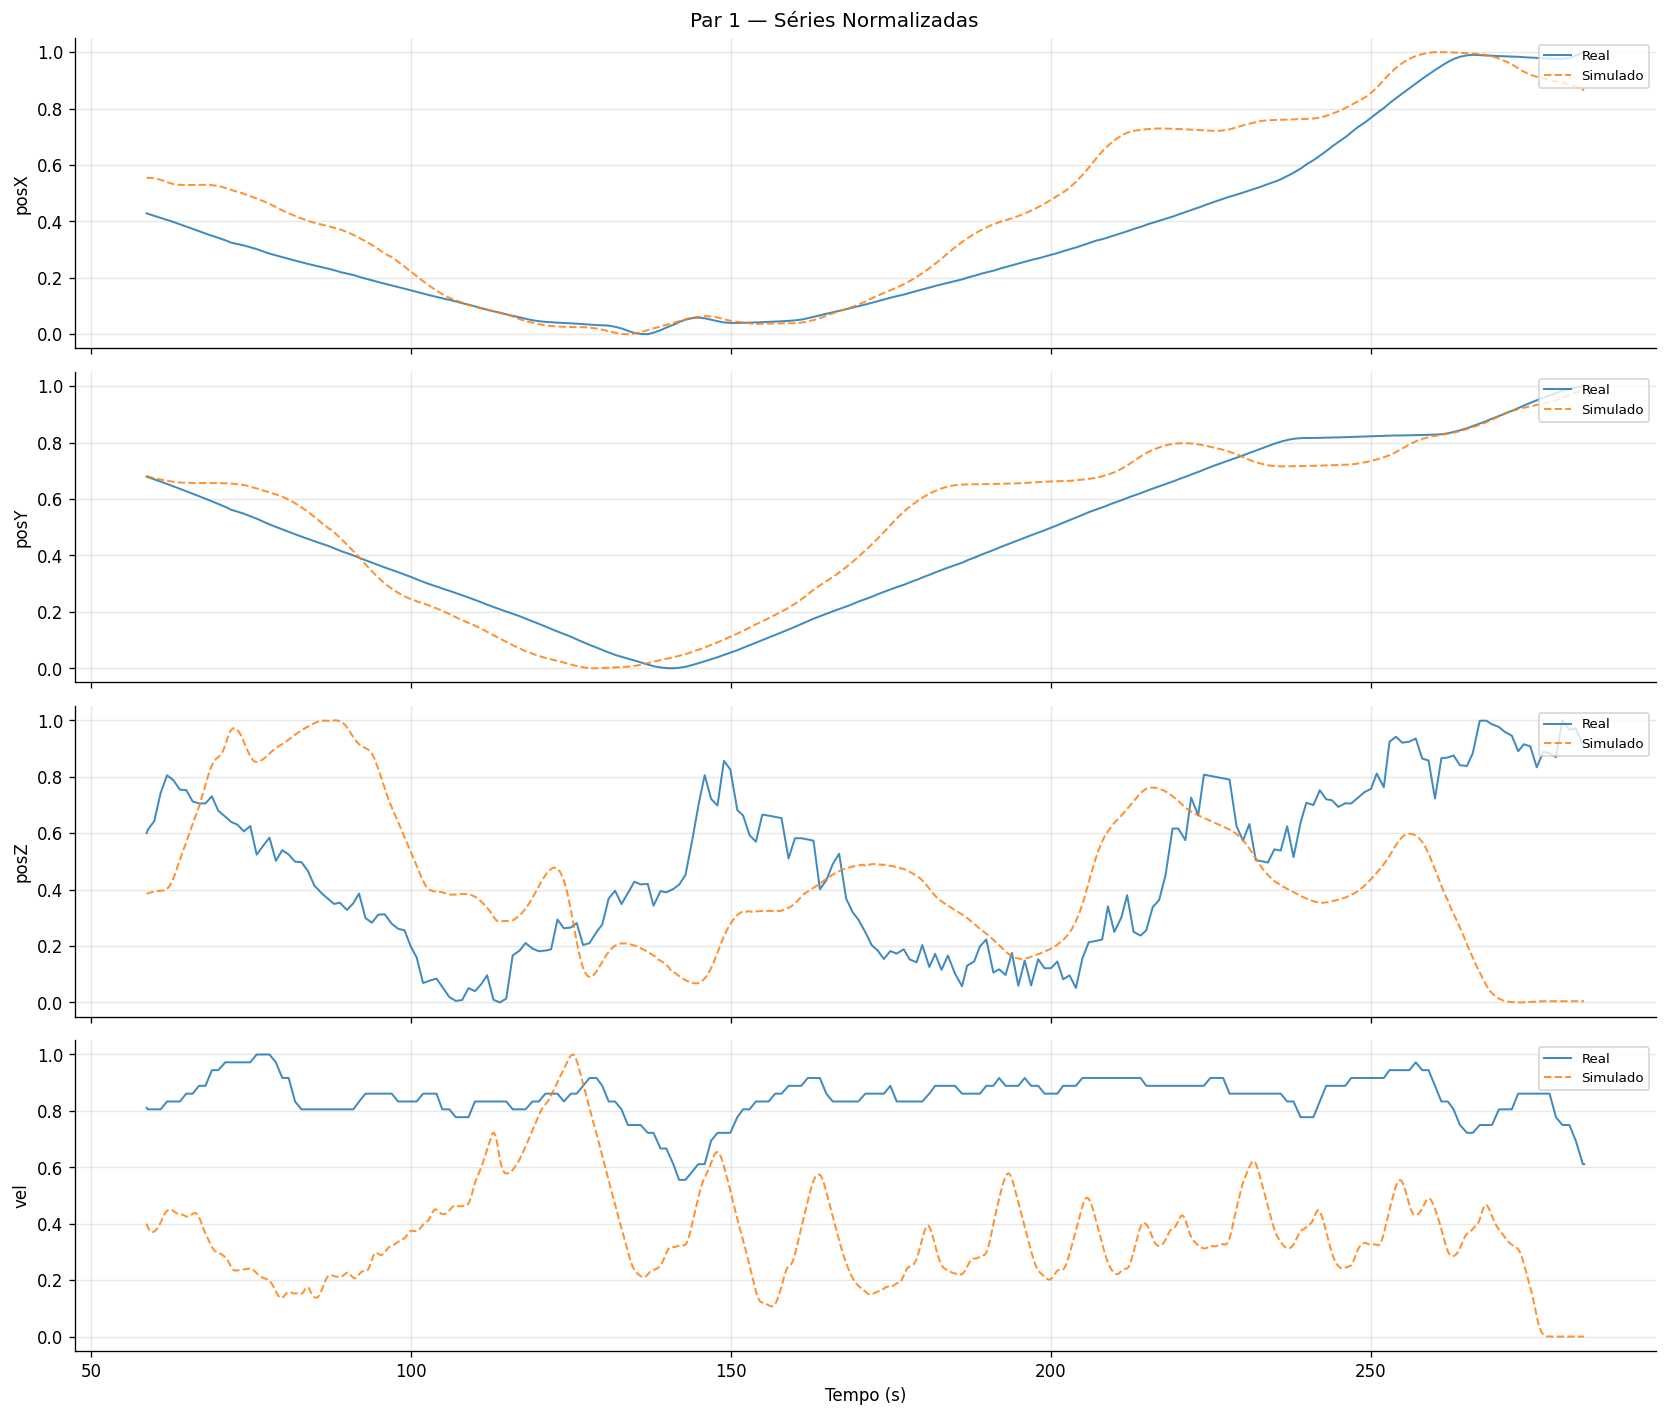

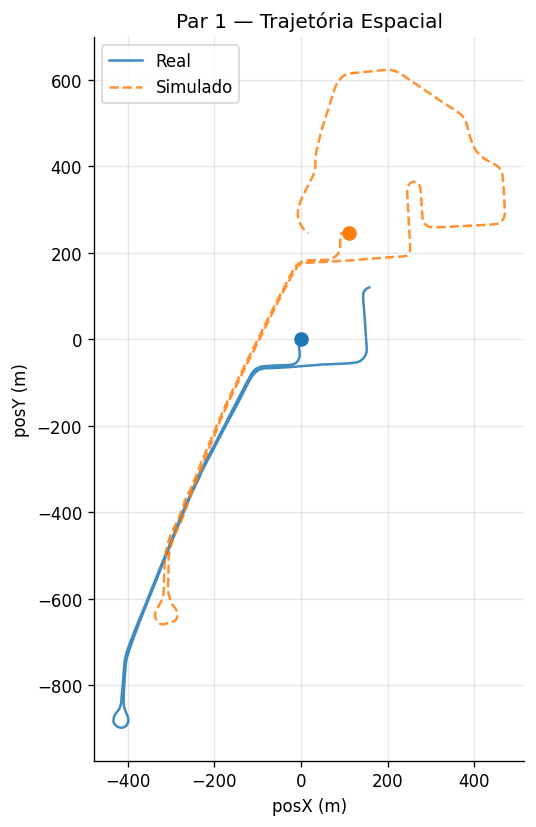

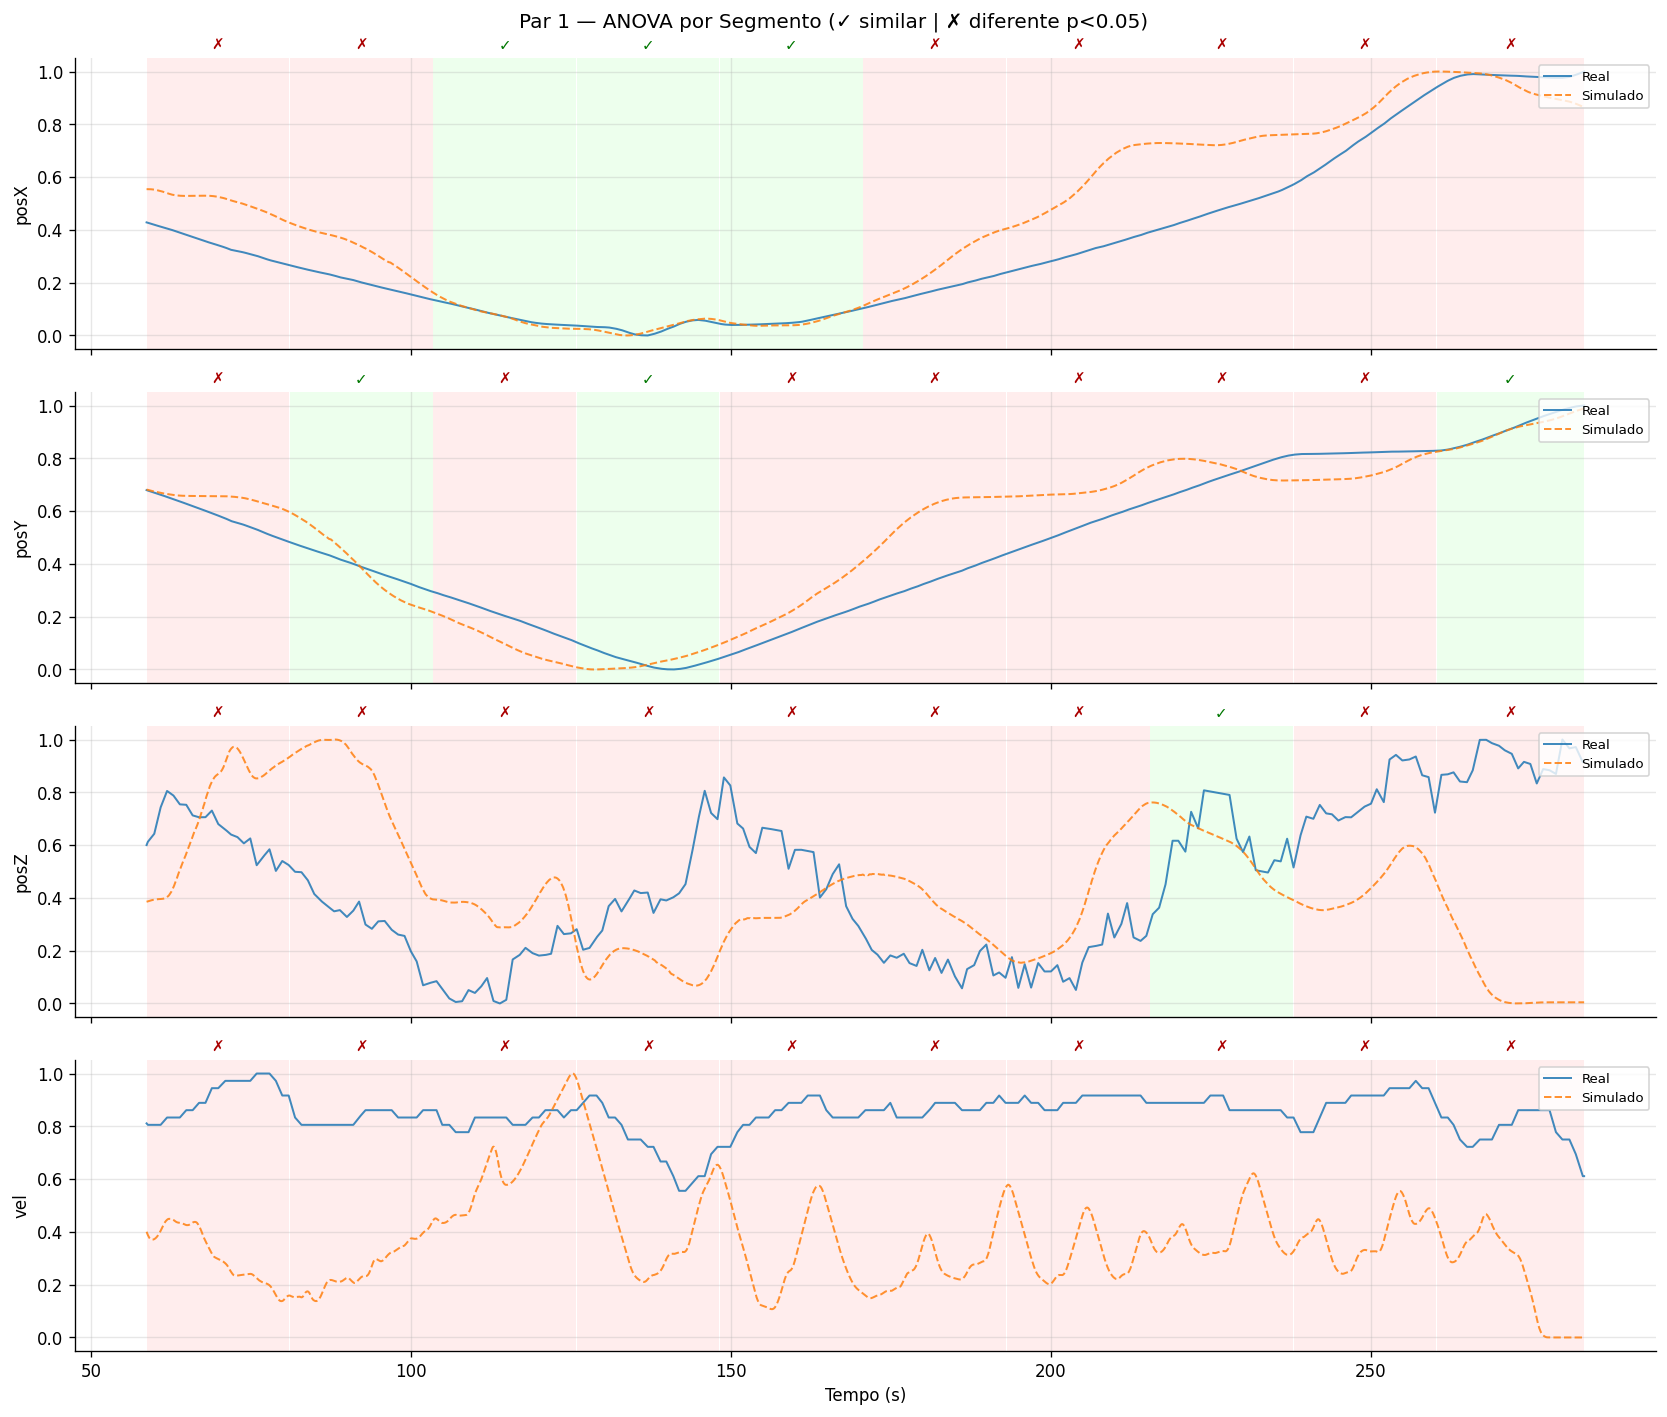

  Variável    Pearson r    DTW sim   ANOVA dif%  Veredicto
  -----------------------------------------------------------------
  posX           0.9449     0.9993          70%  ✗ Divergente
  posY           0.9308     0.9997          70%  ✗ Divergente
  posZ          -0.0710     0.9940          90%  ✗ Divergente
  vel            0.0129     0.9924         100%  ✗ Divergente

Par 2: 10.csv  ×  readable copy.csv
  Duração: 0 days 00:06:52.900000 | Amostras: 2336 | Lags: {'posZ': 0, 'vel': 0, 'posX': 514, 'posY': 359}


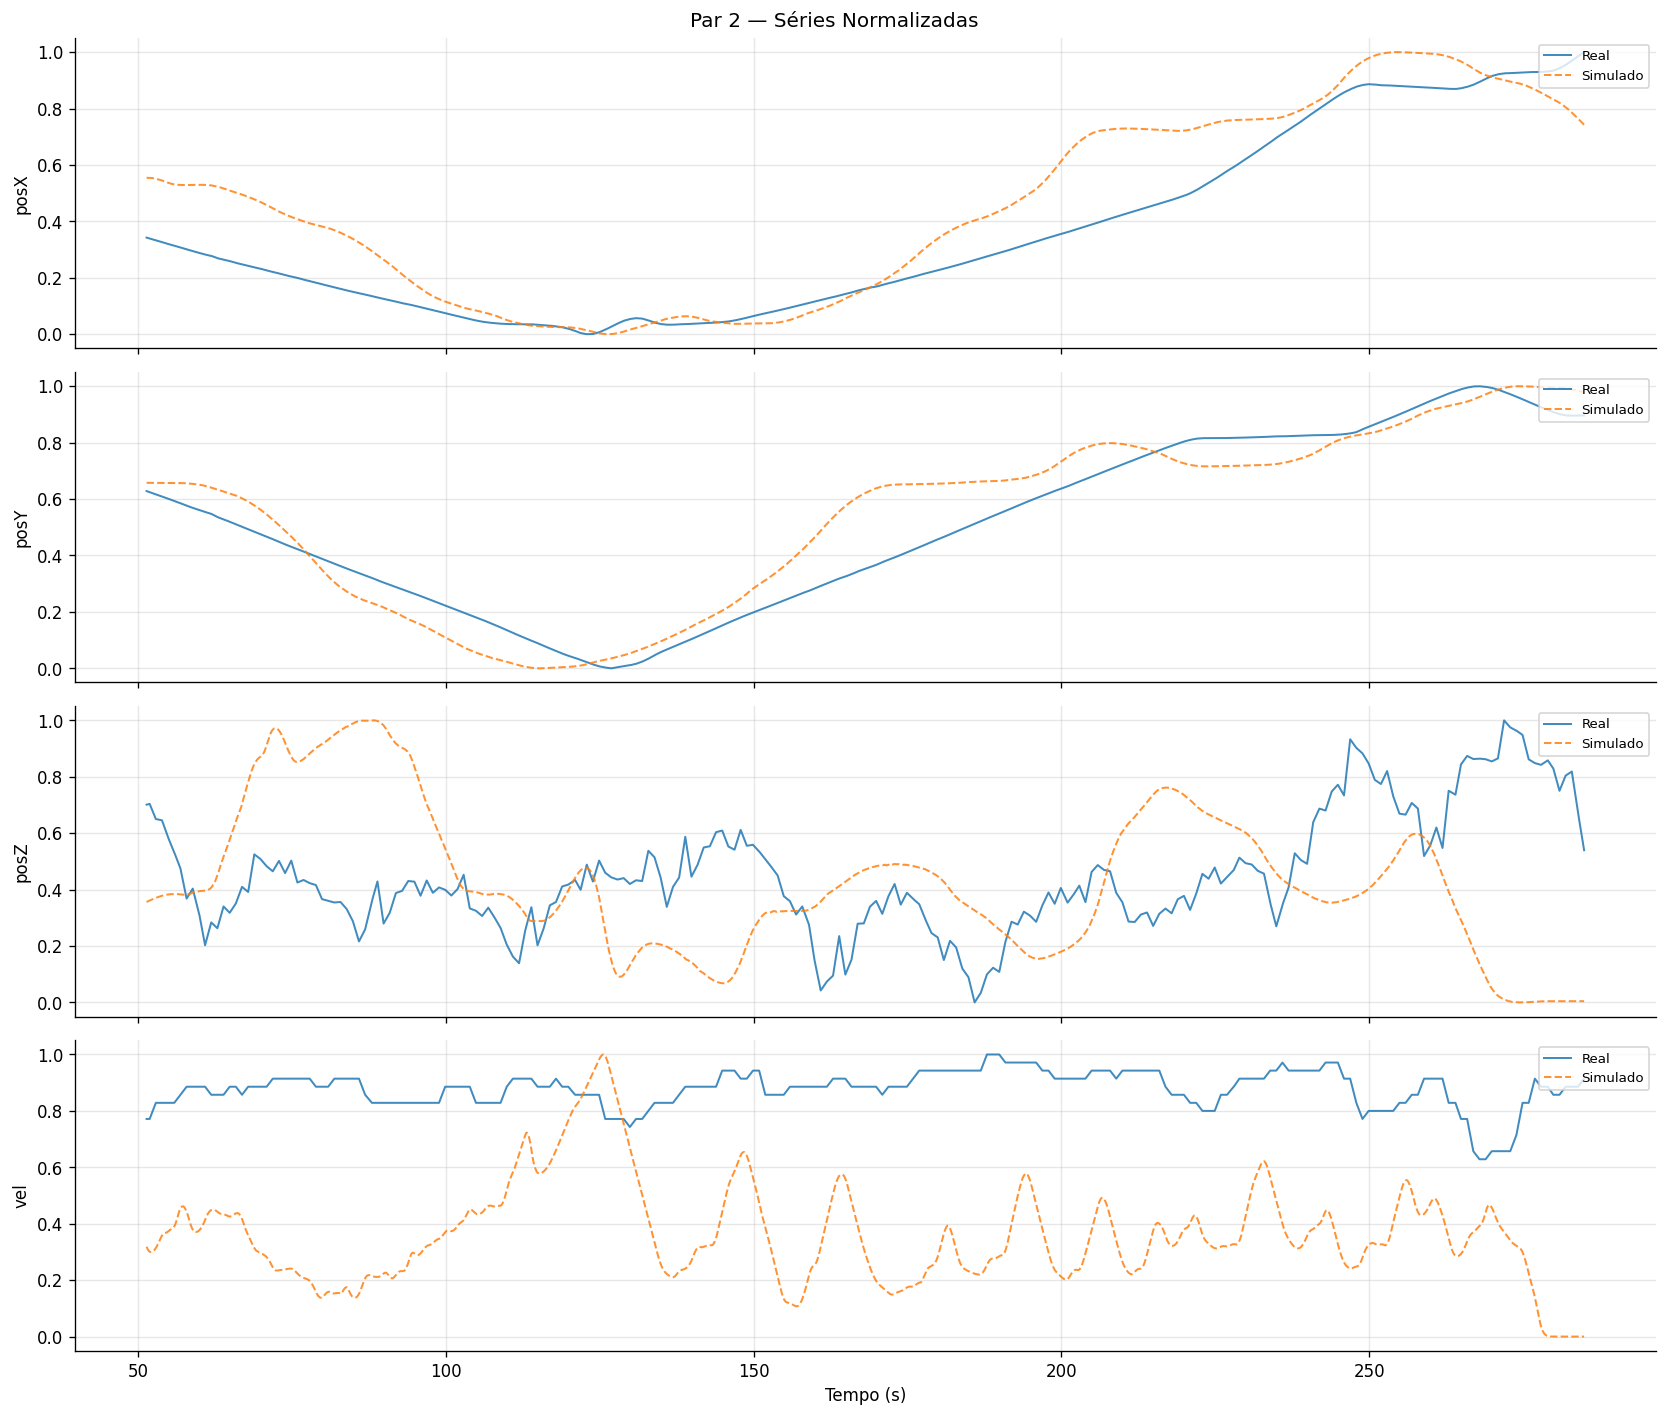

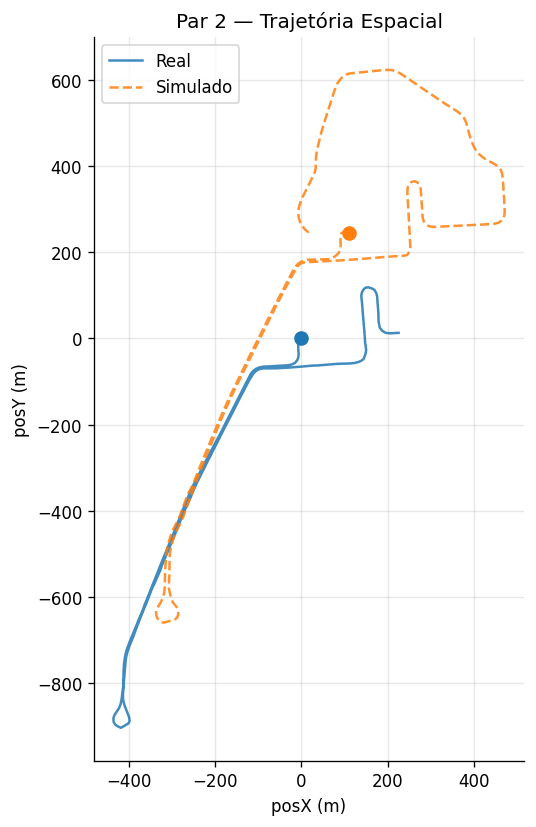

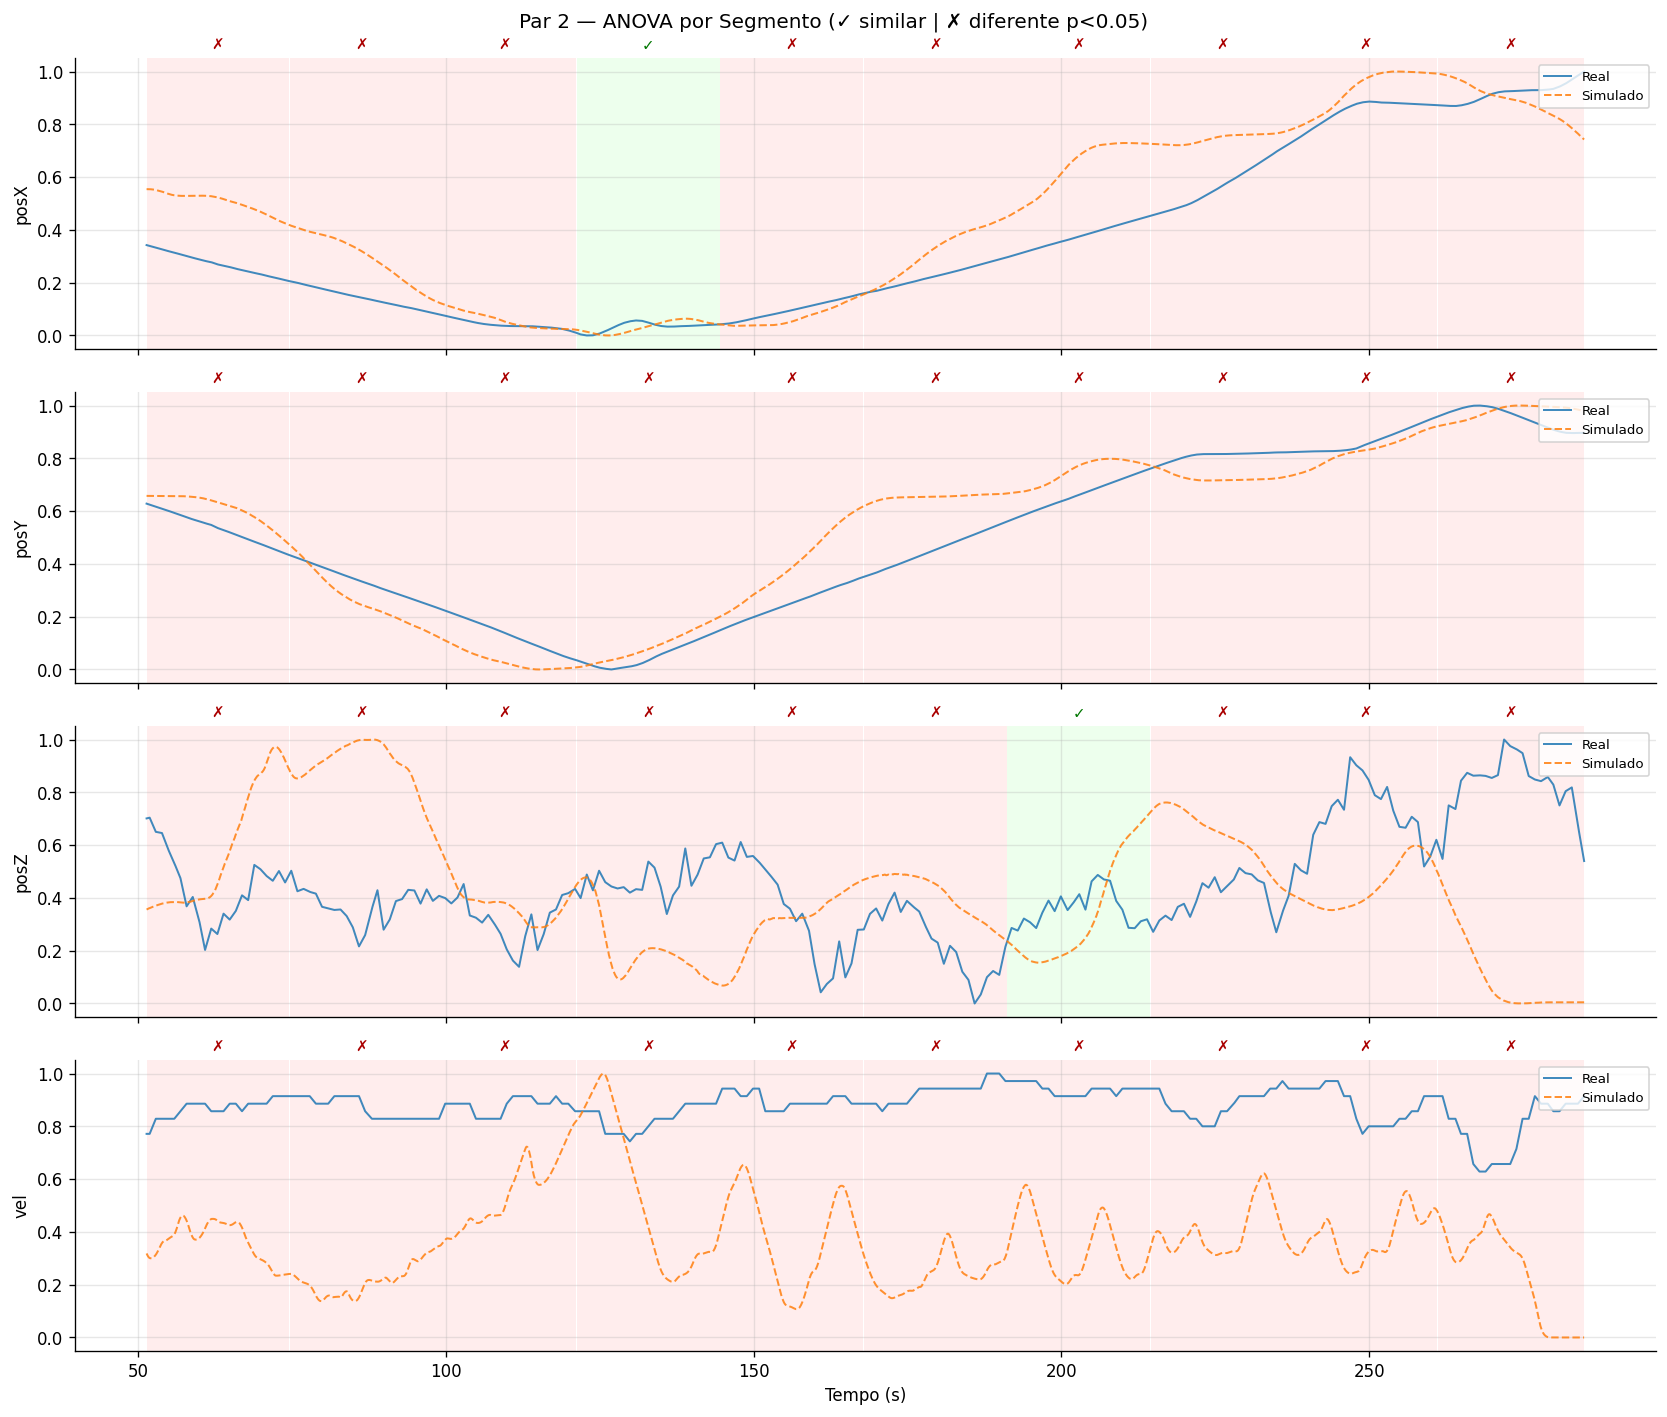

  Variável    Pearson r    DTW sim   ANOVA dif%  Veredicto
  -----------------------------------------------------------------
  posX           0.9404     0.9987          90%  ✗ Divergente
  posY           0.9435     0.9996         100%  ✗ Divergente
  posZ          -0.3222     0.9959          90%  ✗ Divergente
  vel           -0.1076     0.9922         100%  ✗ Divergente

Par 3: 2.csv  ×  readable.csv
  Duração: 0 days 00:07:16.100000 | Amostras: 2306 | Lags: {'posZ': 0, 'vel': 0, 'posX': 547, 'posY': 418}


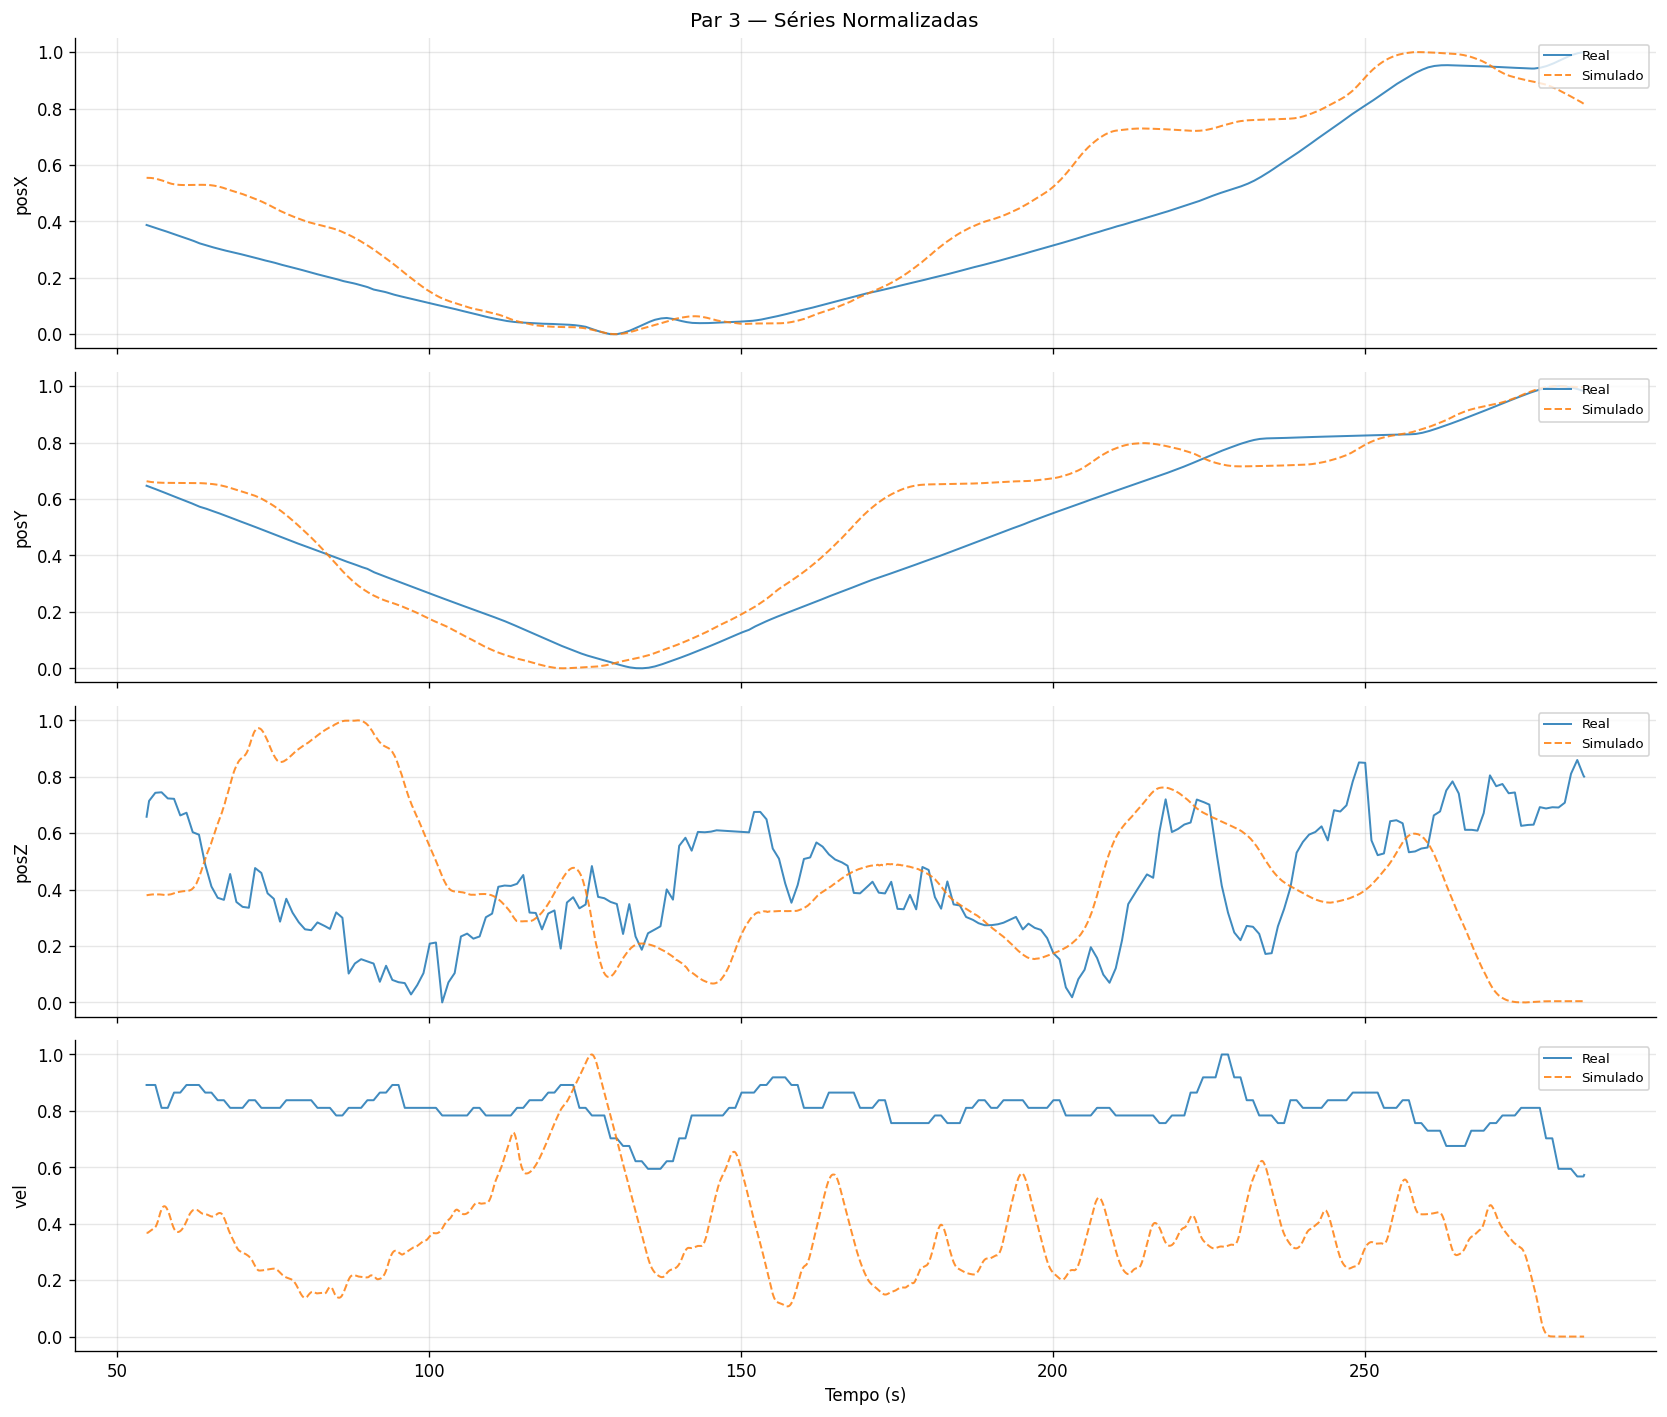

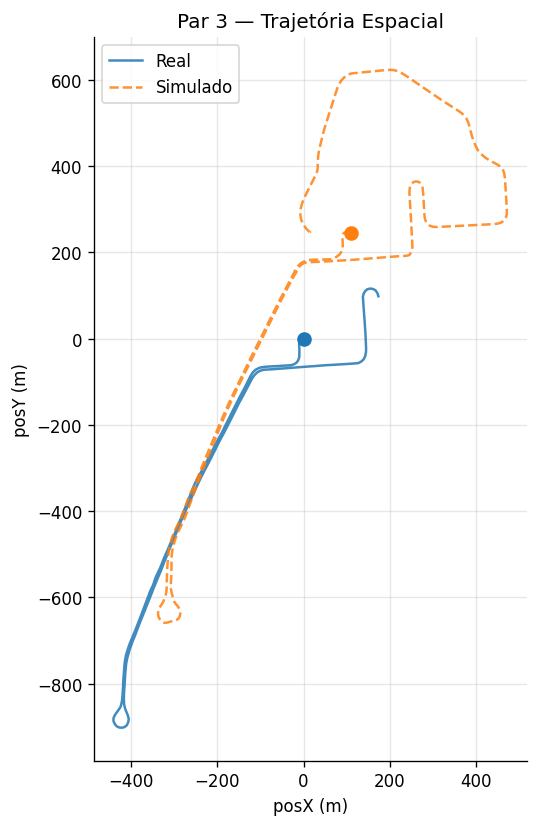

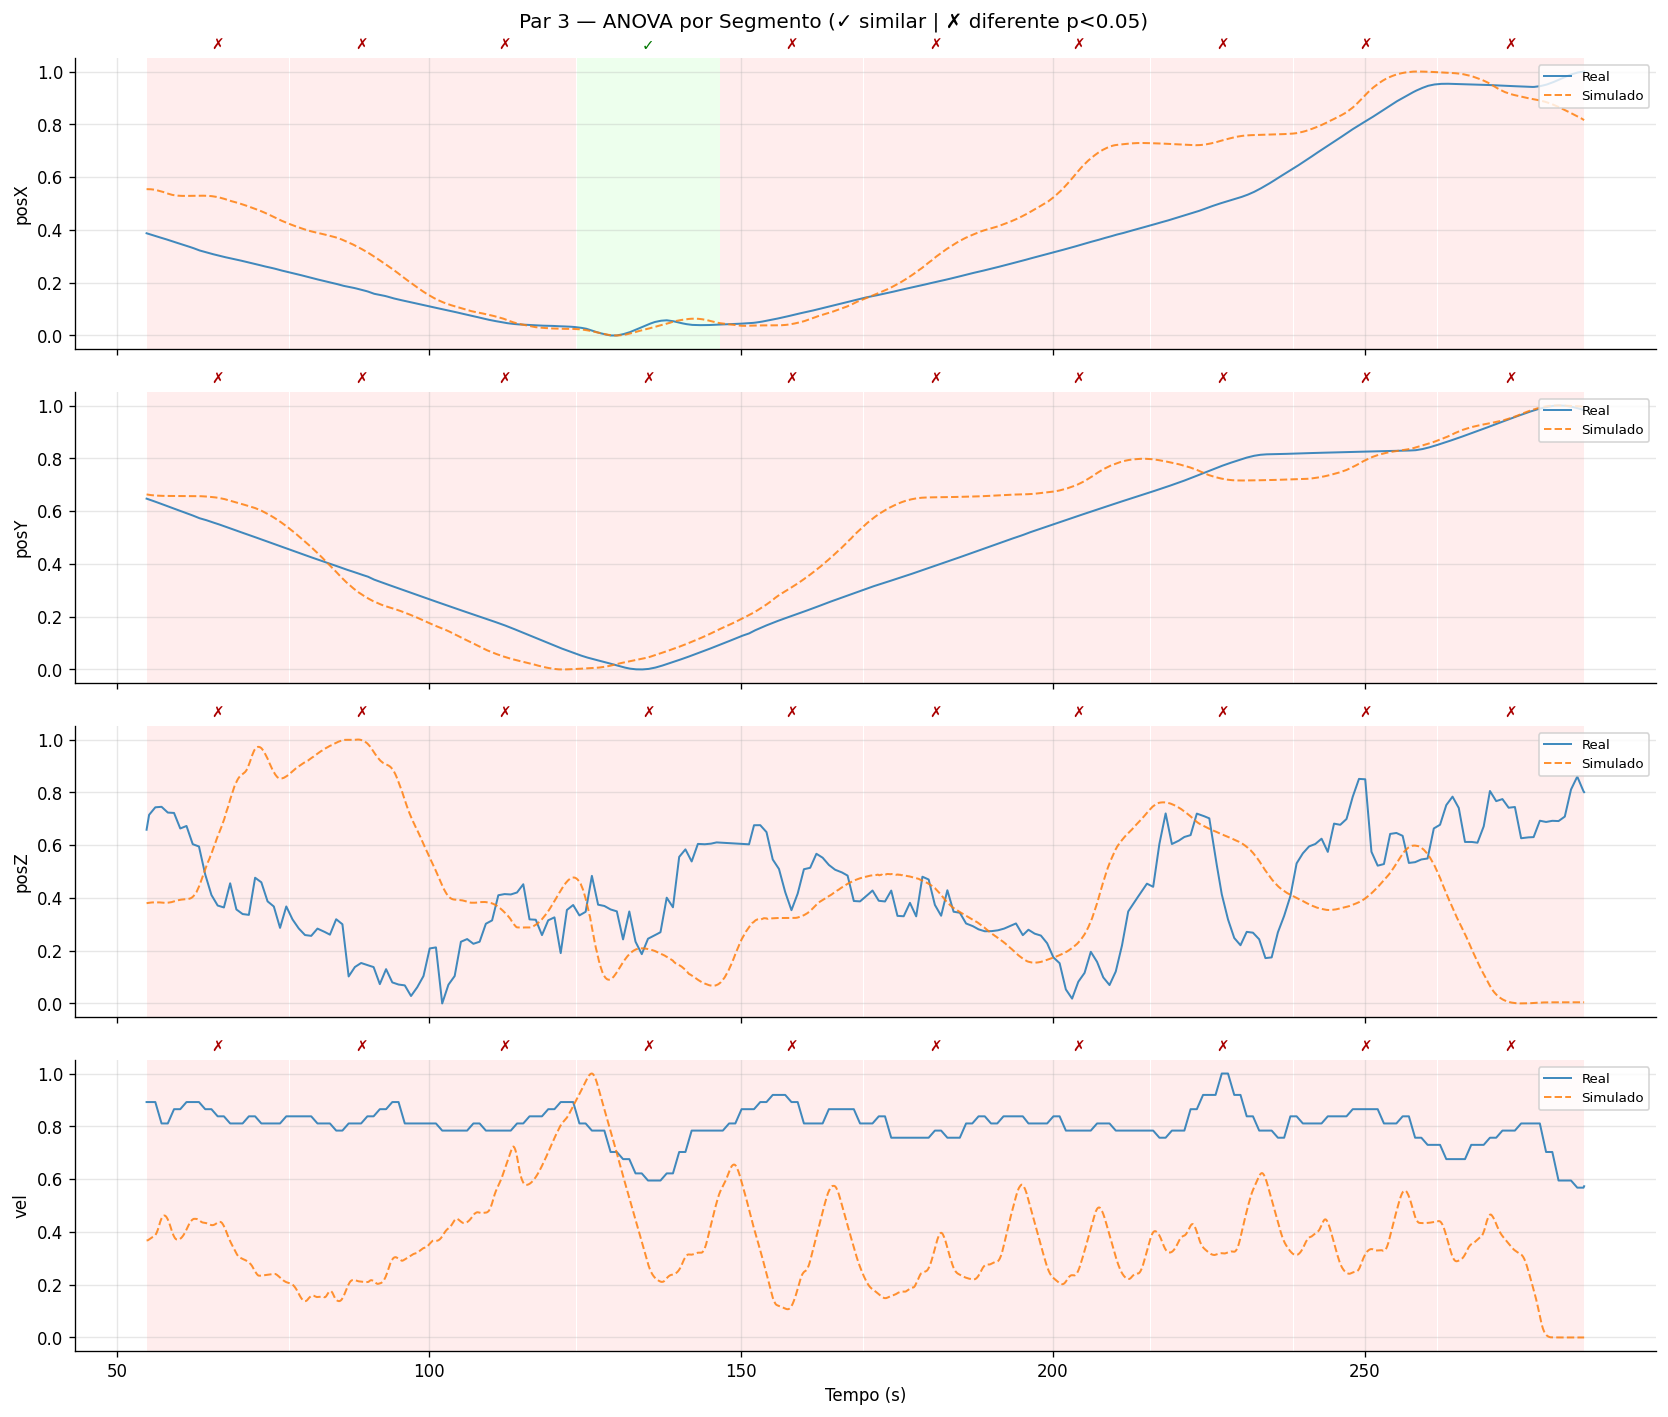

  Variável    Pearson r    DTW sim   ANOVA dif%  Veredicto
  -----------------------------------------------------------------
  posX           0.9424     0.9990          90%  ✗ Divergente
  posY           0.9362     0.9997         100%  ✗ Divergente
  posZ          -0.3392     0.9955         100%  ✗ Divergente
  vel            0.1617     0.9930         100%  ✗ Divergente


Análise individual concluída!
Total de pares processados: 3


In [11]:
# Armazena métricas de todos os pares para o comparativo final
todos_resultados = []   # lista de dicts: {par, nome_real, nome_sim, metricas}

for i in range(n_pares):
    nome_real = arquivos_real[i]
    nome_sim  = arquivos_sim[i]
    label_par = f'Par {i+1}'

    print('=' * 70)
    print(f'{label_par}: {nome_real}  ×  {nome_sim}')
    print('=' * 70)

    # Carregar
    df_real = pd.read_csv(join(PASTA_REAL, nome_real), sep=',', skipinitialspace=True)
    df_sim  = pd.read_csv(join(PASTA_SIMULADO, nome_sim), sep=';')

    # Preparar
    try:
        real     = preparar_real(df_real)
        simulado = preparar_simulado(df_sim)
    except Exception as e:
        print(f'  ERRO na preparação: {e}')
        continue

    # Verificar colunas disponíveis
    colunas_ok = [c for c in COLUNAS_CORR if c in real.columns and c in simulado.columns]
    if not colunas_ok:
        print('  ERRO: nenhuma coluna comparável encontrada')
        continue

    # Alinhar e normalizar
    df, lags, real_c, sim_c = alinhar_e_normalizar(real, simulado, colunas_ok)
    t = df.index.total_seconds().values

    print(f'  Duração: {real.index[-1]} | Amostras: {len(df)} | Lags: {lags}')

    # ── Plot 1: Séries normalizadas ──────────────────────────────────────────
    fig, axes = plt.subplots(len(colunas_ok), 1, figsize=(14, 3 * len(colunas_ok)), sharex=True)
    if len(colunas_ok) == 1:
        axes = [axes]
    for ax, col in zip(axes, colunas_ok):
        ax.plot(t, df[f'real_{col}'],        label='Real',     color='#1f77b4', lw=1.2, alpha=0.85)
        ax.plot(t, df[f'sim_{col}_shifted'], label='Simulado', color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
        ax.set_ylabel(col, fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('Tempo (s)')
    fig.suptitle(f'{label_par} — Séries Normalizadas', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Trajetória espacial ──────────────────────────────────────────
    if 'posX' in colunas_ok and 'posY' in colunas_ok:
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.plot(real_c['posX'],  real_c['posY'],  label='Real',     color='#1f77b4', lw=1.5, alpha=0.85)
        ax.plot(sim_c['posX'],   sim_c['posY'],   label='Simulado', color='#ff7f0e', lw=1.5, alpha=0.85, ls='--')
        ax.scatter(real_c['posX'].iloc[0], real_c['posY'].iloc[0], color='#1f77b4', s=60, zorder=5)
        ax.scatter(sim_c['posX'].iloc[0],  sim_c['posY'].iloc[0],  color='#ff7f0e', s=60, zorder=5)
        ax.set_xlabel('posX (m)')
        ax.set_ylabel('posY (m)')
        ax.set_title(f'{label_par} — Trajetória Espacial')
        ax.legend()
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()

    # ── Calcular métricas ────────────────────────────────────────────────────
    metricas = calcular_metricas(df, colunas_ok, N_SEGMENTOS)

    # ── Plot 3: ANOVA por segmento ───────────────────────────────────────────
    fig, axes = plt.subplots(len(colunas_ok), 1, figsize=(14, 3 * len(colunas_ok)), sharex=True)
    if len(colunas_ok) == 1:
        axes = [axes]
    for ax, col in zip(axes, colunas_ok):
        ax.plot(t, df[f'real_{col}'],        label='Real',     color='#1f77b4', lw=1.2, alpha=0.85)
        ax.plot(t, df[f'sim_{col}_shifted'], label='Simulado', color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
        for seg in metricas[col]['anova_segs']:
            cor = '#ffcccc' if seg['p'] < 0.05 else '#ccffcc'
            ax.axvspan(seg['ini'], seg['fim'], alpha=0.35, color=cor, lw=0)
            ax.text(
                (seg['ini'] + seg['fim']) / 2, 1.02,
                '✗' if seg['p'] < 0.05 else '✓',
                ha='center', va='bottom', fontsize=9,
                color='#aa0000' if seg['p'] < 0.05 else '#007700',
                transform=ax.get_xaxis_transform()
            )
        ax.set_ylabel(col, fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('Tempo (s)')
    fig.suptitle(f'{label_par} — ANOVA por Segmento (✓ similar | ✗ diferente p<0.05)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Tabela de métricas do par ────────────────────────────────────────────
    print(f"  {'Variável':<10} {'Pearson r':>10} {'DTW sim':>10} {'ANOVA dif%':>12}  Veredicto")
    print('  ' + '-' * 65)
    for col in colunas_ok:
        m   = metricas[col]
        r   = m['pearson_r']
        s   = m['dtw_sim']
        pct = m['anova_pct_dif']
        if r > 0.85 and s > 0.85 and pct <= 20:
            verd = '✓ Válido'
        elif r > 0.70 and s > 0.70 and pct <= 50:
            verd = '~ Aceitável'
        else:
            verd = '✗ Divergente'
        print(f"  {col:<10} {r:>10.4f} {s:>10.4f} {pct:>11.0f}%  {verd}")
    print()

    # Guardar para comparativo final
    todos_resultados.append({
        'par':      label_par,
        'nome_real': nome_real,
        'nome_sim':  nome_sim,
        'colunas':  colunas_ok,
        'metricas': metricas,
    })

print('\nAnálise individual concluída!')
print(f'Total de pares processados: {len(todos_resultados)}')

## 5. Comparativo final — todos os pares

Gráfico de barras agrupadas: cada grupo é uma variável,
cada barra é um par de arquivos.

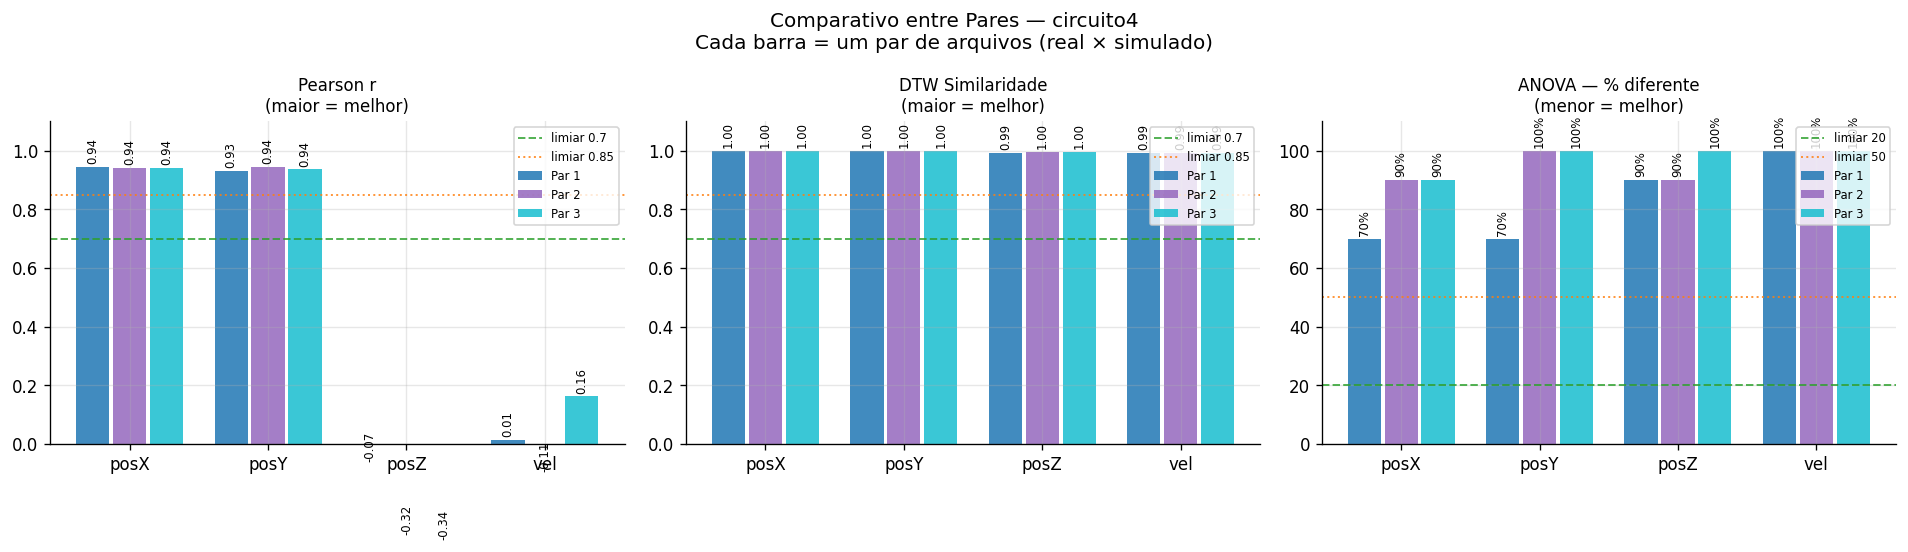

TABELA COMPARATIVA — todos os pares
Par       Variável   Pearson r    DTW sim   ANOVA dif%  Veredicto
-------------------------------------------------------------------------------------
Par 1     posX           0.9449     0.9993          70%  ✗ Divergente
Par 1     posY           0.9308     0.9997          70%  ✗ Divergente
Par 1     posZ          -0.0710     0.9940          90%  ✗ Divergente
Par 1     vel            0.0129     0.9924         100%  ✗ Divergente

Par 2     posX           0.9404     0.9987          90%  ✗ Divergente
Par 2     posY           0.9435     0.9996         100%  ✗ Divergente
Par 2     posZ          -0.3222     0.9959          90%  ✗ Divergente
Par 2     vel           -0.1076     0.9922         100%  ✗ Divergente

Par 3     posX           0.9424     0.9990          90%  ✗ Divergente
Par 3     posY           0.9362     0.9997         100%  ✗ Divergente
Par 3     posZ          -0.3392     0.9955         100%  ✗ Divergente
Par 3     vel            0.1617     0.99

In [12]:
if len(todos_resultados) < 2:
    print('Apenas 1 par processado — comparativo não aplicável.')
else:
    n_pares_ok = len(todos_resultados)
    colunas_comuns = COLUNAS_CORR  # usa a lista original; pares sem a coluna ficam NaN

    # Montar matrizes: linhas=pares, colunas=variáveis
    mat_pearson = np.full((n_pares_ok, len(colunas_comuns)), np.nan)
    mat_dtw     = np.full((n_pares_ok, len(colunas_comuns)), np.nan)
    mat_anova   = np.full((n_pares_ok, len(colunas_comuns)), np.nan)

    for pi, res in enumerate(todos_resultados):
        for ci, col in enumerate(colunas_comuns):
            if col in res['metricas']:
                m = res['metricas'][col]
                mat_pearson[pi, ci] = m['pearson_r']
                mat_dtw[pi, ci]     = m['dtw_sim']
                mat_anova[pi, ci]   = m['anova_pct_dif']

    labels_par = [r['par'] for r in todos_resultados]
    x          = np.arange(len(colunas_comuns))
    width      = 0.8 / n_pares_ok
    cores_par  = plt.cm.tab10(np.linspace(0, 0.9, n_pares_ok))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    titulos = [
        ('Pearson r',          mat_pearson, (0, 1.1),  [0.70, 0.85], 'maior = melhor'),
        ('DTW Similaridade',   mat_dtw,     (0, 1.1),  [0.70, 0.85], 'maior = melhor'),
        ('ANOVA — % diferente', mat_anova,  (0, 110),  [20,   50],   'menor = melhor'),
    ]

    for ax, (titulo, mat, ylim, limiares, nota) in zip(axes, titulos):
        for pi in range(n_pares_ok):
            offset = (pi - n_pares_ok / 2 + 0.5) * width
            vals   = mat[pi]
            bars   = ax.bar(
                x + offset, vals, width=width * 0.9,
                color=cores_par[pi], alpha=0.85,
                label=labels_par[pi]
            )
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + ylim[1] * 0.01,
                        f'{val:.2f}' if titulo != 'ANOVA — % diferente' else f'{val:.0f}%',
                        ha='center', va='bottom', fontsize=7, rotation=90
                    )

        cores_lim = ['#2ca02c', '#ff7f0e']
        estilos   = ['--', ':']
        for lim, cor, est in zip(limiares, cores_lim, estilos):
            ax.axhline(lim, color=cor, ls=est, lw=1.2, alpha=0.8, label=f'limiar {lim}')

        ax.set_xticks(x)
        ax.set_xticklabels(colunas_comuns)
        ax.set_ylim(*ylim)
        ax.set_title(f'{titulo}\n({nota})', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')

    fig.suptitle(
        f'Comparativo entre Pares — {PASTA_REAL.split("/")[0]}\n'
        'Cada barra = um par de arquivos (real × simulado)',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # ── Tabela resumo comparativo ────────────────────────────────────────────
    print('=' * 85)
    print('TABELA COMPARATIVA — todos os pares')
    print('=' * 85)
    header = f"{'Par':<8}  {'Variável':<10}" + \
             f"{'Pearson r':>10} {'DTW sim':>10} {'ANOVA dif%':>12}  Veredicto"
    print(header)
    print('-' * 85)

    for res in todos_resultados:
        for col in res['colunas']:
            m   = res['metricas'][col]
            r   = m['pearson_r']
            s   = m['dtw_sim']
            pct = m['anova_pct_dif']
            if r > 0.85 and s > 0.85 and pct <= 20:
                verd = '✓ Válido'
            elif r > 0.70 and s > 0.70 and pct <= 50:
                verd = '~ Aceitável'
            else:
                verd = '✗ Divergente'
            print(f"{res['par']:<8}  {col:<10} {r:>10.4f} {s:>10.4f} {pct:>11.0f}%  {verd}")
        print()

    print('=' * 85)